# Raport: Wykrywanie naczyń dna siatkówki oka

https://github.com/viatrix17/Wykrywanie-naczyn-dna-siatkowki-oka

#### Skład grupy

Julia Kardasz 160204
Szymon Wójtowicz 160109

### Biblioteki

In [63]:
import os
import random
import matplotlib.pyplot as plt
from scipy import misc
import numpy as np
from PIL import Image
import skimage
from skimage import exposure, filters, morphology, color
from skimage.util import view_as_windows
from skimage.measure import moments, moments_central, moments_hu, moments_normalized
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Implementacja

## Wczytywanie plików 

In [2]:
def open_image_file(path):
    print(f"Opening file {path}")
    if os.path.exists(path):
        img = Image.open(path).convert('RGB')
        root, extension = os.path.splitext(path)
    else:
        print("Nie można znaleźć pliku 1.")
    img = np.array(img)

    return img

## Wstępne przetwarzanie obrazu

In [3]:
def extract_channels(img):
    r = img.copy()
    r[:,:,1] = r[:,:,2] = 0

    g = img.copy()
    g[:,:,0] = g[:,:,2] = 0

    b = img.copy()
    b[:,:,0] = b[:,:,1] = 0

    return r,g,b

def preprocess_image(img):
    print("Preprocessing the image...")
    # normalization
    img_eq = exposure.equalize_adapthist(img)
    # noise reduction
    img_clean = filters.median(img_eq)
    return img_clean

## Właściwe przetworzenie obrazu

In [4]:
def display_color_components(r, g, b):
    print("Displaying color components...")
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Wyświetlenie kanałów w skali szarości ('gray')
    axes[0].imshow(r, cmap='gray')
    axes[0].set_title('Red Channel')
    axes[0].axis('off')
    
    axes[1].imshow(g, cmap='gray')
    axes[1].set_title('Green Channel')
    axes[1].axis('off')
    
    axes[2].imshow(b, cmap='gray')
    axes[2].set_title('Blue Channel')
    axes[2].axis('off')
    
    plt.show()

Składowe niebieskie i czerwone dostarczają nam bardzo niewiele danych, w związku z czym nie używamy ich do szukania naczyń krwionośnych

#### Użycie zielonej składowej oraz filtra Frangiego do znalezienia naczyń krwionośnych

In [5]:
def filter(g):
    print("Filtering with Frangi filter..")
    grey = color.rgb2gray(g)
    f=skimage.filters.frangi(grey)
    pixels=0
    prog=0.01
    contrast_pixels=0
    classified_points = f.copy()
    for i in range(0,f.shape[0]):
        for j in range(0,f.shape[1]):
            if f[i][j]>prog:
                contrast_pixels+=1
                classified_points[i][j]=1
            else:
                classified_points[i][j]=0
            pixels+=1
            
    print(str(contrast_pixels) + " out of " + str(pixels) + " pixels are in high contrast, which means about " + str(contrast_pixels/pixels*100) +"%" + " the eye is blood vessels")
    #plt.imshow(grey, cmap=plt.get_cmap('gray'), vmin=0, vmax=1)
    plt.imshow(classified_points, cmap=plt.get_cmap('gray'), vmin=0, vmax=1)
    plt.show()
    print("Filtering finished.")
    return classified_points

## Końcowe przetwarzanie

In [6]:
def postprocess_segmentation(mask):
    # szum deletion
    corrected_mask = morphology.remove_small_objects(mask.astype(bool), min_size=50)
    corrected_mask = morphology.closing(corrected_mask, morphology.disk(2))
    return corrected_mask

#### Porównanie złotego standardu z naszą maską

In [7]:
def compare_with_ground_truth(custom_mask, gold_mask):
    print("Comparing with ground truth...")    
    gold_mask = np.array(gold_mask)
    #print(gold_mask)
    gold_maks = color.rgb2gray(gold_mask)
    plt.imshow(gold_mask, cmap=plt.get_cmap('gray'), vmin=0, vmax=1)

    l=0
    m=0
    for i in range(0,custom_mask.shape[0]):
        for j in range(0,custom_mask.shape[1]):
            if custom_mask[i][j] == gold_mask[i][j].any():
                l+=1
            m+=1
    print("Zgodność maski i maski eksperckiej: ", l/m)

    # ADD: sensitivity and specifity

WNIOSKI DODAĆ

## Uczenie maszynowe
### Przygotowanie danych

In [ ]:
window_shape = (5,5)

def extract_features(window):
    var = np.var(window)
    M = moments(window)

    cm = np.zeros((3, 3))
    central_moments = np.zeros((3, 3))
    rows, cols = cm.shape
    
    hu_moments = np.zeros(7)
    if M[0,0] > 0:
        centroid = (M[1, 0] / M[0, 0], M[0, 1] / M[0, 0])
        cm = moments_central(window, center=(centroid[1], centroid[0]), order=2)
        rows, cols = cm.shape
        central_moments[:rows, :cols] = cm
        nu = moments_normalized(central_moments, order=2)
        if nu[0, 0] > 0:
            hu_moments = moments_hu(nu)

    features = np.concatenate(([var], central_moments.flatten(), hu_moments))
    return features

def sliding_window(img, ground_truth): 
    img_gray = color.rgb2gray(img)
    gt_gray = color.rgb2gray(ground_truth)

    X = []
    y = []
    center = window_shape[0] // 2
    windows = view_as_windows(img_gray, window_shape, step=1)
    gt_windows = view_as_windows(gt_gray, window_shape, step=1)

    h_steps, w_steps = windows.shape[0], windows.shape[1]
    for i in range (h_steps):
        for j in range(w_steps):
            window = windows[i,j]

            features = extract_features(window)
            label = gt_windows[i,j,center,center]

            X.append(features)
            y.append(label)

    return np.array(X), np.array(y)

def get_samples(img, ground_truth, n_per_class=10000):
    print("Getting samples...")
    img_gray = color.rgb2gray(img)
    gt_gray = color.rgb2gray(ground_truth)

    vessel_coords = np.argwhere(gt_gray==1)
    bg_coords = np.argwhere(gt_gray==0)

    # undersampling
    idx_v = np.random.choice(len(vessel_coords), min(n_per_class, len(vessel_coords)), replace=False)
    idx_b = np.random.choice(len(bg_coords), min(n_per_class, len(bg_coords)), replace=False)
    
    coords = np.vstack((vessel_coords[idx_v], bg_coords[idx_b]))

    X, y = [], []

    offset = window_shape[0] // 2 
    # 2 for window shape (5,5)

    for r,c in coords: # r,c - coords of the middle of the window
        if r >= offset and r < img_gray.shape[0]-offset and c >= offset and c < img_gray.shape[1]-offset:
            window = img_gray[r-offset:r+offset+1, c-offset:c+offset+1]
            features = extract_features(window)
            label = gt_gray[r,c]

            X.append(features)
            y.append(label)
            
        
    return np.array(X), np.array(y)
    

### Klasyfikator

In [66]:
def classify(X,y):
    print("Classifying with KNN classifier...")
    X = np.array(X).astype(float)
    y = np.array(y).astype(int)
    X_train, X_test, y_train, y_test = train_test_split(X, y , test_size = 0.3, random_state=42)

    neigh = KNeighborsClassifier(n_neighbors=3)
    
    neigh.fit(X_train, y_train)
    y_pred = neigh.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    print("Classification_report:")
    print(classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=neigh.classes_)
    disp.plot(cmap="Blues")
    plt.show()
    
    tn, fp, fn, tp = cm.ravel()

    sen = tp/(tp+fn)
    spec = tn/(tn+fp)

    print(f"Accuracy: {acc}\nSensitivity: {sen}\nSensitivity: {spec}")
    

### Uczenie głębokie - sieć neuronowa

# Przykład działania programu

Opening file 01_h_goldstandard.bmp
Opening file 01_h.jpg
Preprocessing the image...
Displaying color components...


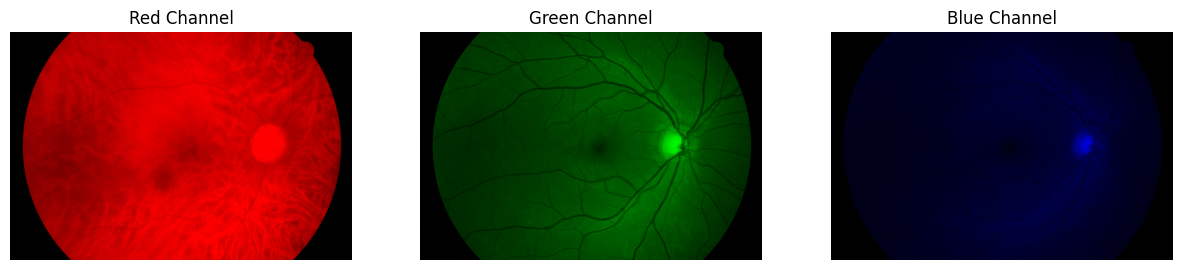

Filtering with Frangi filter..
423100 out of 8185344 pixels are in high contrast, which means about 5.168994730093201% the eye is blood vessels


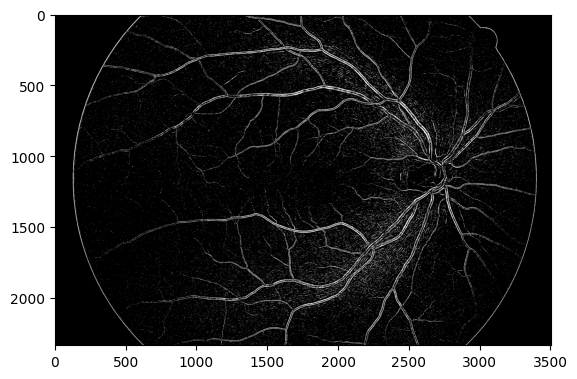

Filtering finished.


/tmp/ipykernel_45196/400329806.py:3: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  corrected_mask = morphology.remove_small_objects(mask.astype(bool), min_size=50)


Comparing with ground truth...
Zgodność maski i maski eksperckiej:  0.9183168111199724


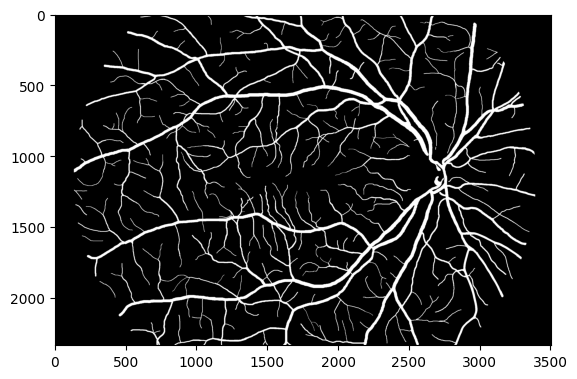

In [10]:
paths = {
    "1": "01_h.jpg"
    # "2": "01_h.jpg"
}

images = []

gruond_truth_path = "01_h_goldstandard.bmp"
ground_truth = open_image_file(gruond_truth_path)

for number, path in paths.items():
    img = open_image_file(path)
    images.append(img)

def custom_algorithm(img):
    preprocess_image(img)
    display_color_components(r,g,b)
    mask = filter(g)
    final_mask = postprocess_segmentation(mask)
    compare_with_ground_truth(final_mask, ground_truth)

for img in images:
    r,g,b = extract_channels(img)
    custom_algorithm(img)
    

## Zastosowanie uczenia maszynowego i ocena modelu

Getting samples...
[[ 4.63734706e-04  8.81985529e+00  9.02937255e-01 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 7.89436256e-04  9.92581137e+00 -5.32112549e-01 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 2.63574690e-05  6.71271569e+00  3.41635294e-02 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 ...
 [ 3.07789125e-06  4.90545098e-02 -3.64713725e-02 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 3.20752879e-05  8.75937373e+00 -1.95987059e-01 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 9.86416255e-05  6.59082196e+00 -2.26011765e-02 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]] [1. 1. 1. ... 0. 0. 0.]
Classifying with KNN classifier...
Classification_report:
              precision    recall  f1-score   support

           0       0.69      0.81      0.75      2992
           1       0.77      0.64      0.70      2994

    accuracy                           0.73      5986
   macro avg       0.73      0.73      0.72  

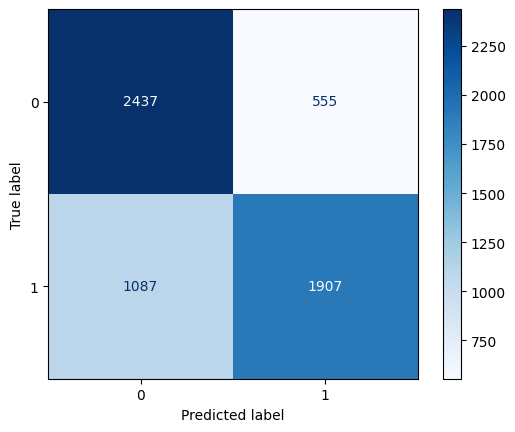

Accuracy: 0.7256932843301036
Sensitivity: 0.636940547762191
Sensitivity: 0.8145053475935828


In [ ]:
def machine_learning(img):
    X,y = get_samples(img,ground_truth)
    print(X,y)
    classify(X,y)

learning_img =
machine_learning(learning_img)